# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



In [53]:
import numpy as np
import pandas as pd

class MyBinaryLogisticRegression:
    def __init__(
        self,
        lr = 0.01,
        n_iter = 1000,
        method = "gd",
        penalty=None,
        lambda1=0.0,
        lambda2=0.0,
        batch_size=1
    ):
        self.lr = lr
        self.n_iter = n_iter
        self.method = method
        self.penalty = penalty
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.batch_size = batch_size
        self.coefs_ = None
        self.feature_names_in_ = None

    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-z))
    
    def _loss_grad(self,X,y):
        p = self._sigmoid(X @ self.coefs_)
        grad = X.T @ (p - y) / len(y)
        if self.penalty == "l2":
            grad += self.lambda2 * self.coefs_
        
        elif self.penalty == "l1":
            grad += self.lambda1 * np.sign(self.coefs_)
            
        elif self.penalty == "l1l2":
            grad += (
                self.lambda1 * np.sign(self.coefs_) +
                self.lambda2 * self.coefs_
            )
            
        return grad
    def fit(self, X: pd.DataFrame, y: pd.DataFrame):
        X = X.values
        y = y.values
        
        n_samples,n_features = X.shape
        self.coefs_ = np.zeros(n_features)
        
        if self.method == "newton" and self.penalty != "l2":
            raise ValueError("Newton method requires L2 regularization")
        
        for _ in range(self.n_iter):
            if self.method == "gd":
                grad = self._loss_grad(X,y)
                self.coefs_ -= self.lr * grad
            
            elif self.method == "sgd":
                idx = np.random.choice(n_samples, self.batch_size)
                grad = self._loss_grad(X[idx], y[idx])
                self.coefs_ -= self.lr * grad
                
            elif self.method == "newton":
                p = self._sigmoid(X @ self.coefs_)
                W = np.diag(p * (1 - p))
                H = X.T @ W @ X / n_samples
                H += self.lambda2 * np.eye(n_features)
                
                grad = self._loss_grad(X,y)
                self.coefs_ -= np.linalg.solve(H, grad)
                
        return self
    def predict(self, X: np.array):
        probs = self._sigmoid(X @ self.coefs_)
        return (probs >= 0.5).astype(int)
    

    def score(self, X: np.array, y: np.array):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import copy

data = pd.read_csv("penguins_binary_classification.csv")
print(data.info())
print(data["species"].unique())
print(data["island"].unique())
y = data["species"]
X = data.drop(columns=["species"])

one_hot_dataframe = copy.deepcopy(X)
def transform_one_hot(st,item):
    return (st == item) * 1
for i in one_hot_dataframe["island"].unique():
    one_hot_dataframe[f"{i}"] = one_hot_dataframe[f"island"].apply(
        lambda x: transform_one_hot(x,i))
# print(one_hot_dataframe.info())
one_hot_dataframe = one_hot_dataframe.drop(columns=["island"])
data = data.dropna()
print(X.info())
classes = y.unique()
class_to_idx = {c: i for i,c in enumerate(classes)}
idx_to_class = {i: c for c,i in class_to_idx.items()}

y_encode = y.map(class_to_idx).values


class TargetEncoder:
    def fit(self,X:pd.Series, y:np.ndarray):
        self.mapping_ = dict()
        self.global_mean_ = y.mean()
        
        for cat in X.unique():
            self.mapping_[cat] = y[X == cat].mean()
            
        return self
    
    def transform(self,X:pd.Series):
        return X.map(self.mapping_).fillna(self.global_mean_)
    
    def fit_transform(self,X:pd.Series,y:np.ndarray):
        self.fit(X, y)
        return self.transform(X)

X_target = copy.deepcopy(X)
te = TargetEncoder()
X_target["island"] = te.fit_transform(X_target["island"],y_encode)

scaler_oh = StandardScaler()
scaler_te = StandardScaler()

X_oh_scaled = scaler_oh.fit_transform(one_hot_dataframe)
X_te_scaled = scaler_te.fit_transform(X_target)

X_train_oh, X_test_oh, y_train, y_test = train_test_split(
    X_oh_scaled, y_encode, test_size=0.3,random_state=42,stratify=y_encode
)

X_train_te, X_test_te, _, _ = train_test_split(
    X_te_scaled, y_encode,test_size=0.3,random_state=42,stratify=y_encode
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            274 non-null    object 
 1   island             274 non-null    object 
 2   bill_length_mm     274 non-null    float64
 3   bill_depth_mm      274 non-null    float64
 4   flipper_length_mm  274 non-null    float64
 5   body_mass_g        274 non-null    float64
 6   year               274 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 15.1+ KB
None
['Adelie' 'Gentoo']
['Torgersen' 'Biscoe' 'Dream']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   island             274 non-null    object 
 1   bill_length_mm     274 non-null    float64
 2   bill_depth_mm      274 non-null    float64
 

Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

In [56]:
class OvRLogisticRegression:
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.models = {}
        
    def fit(self,X ,y):
        self.classes_ = np.unique(y)
        
        for c in self.classes_:
            y_binary = (y == c).astype(int)
            model = MyBinaryLogisticRegression(**self.kwargs)
            model.fit(pd.DataFrame(X), pd.Series(y_binary))
            self.models[c] = model
            
        return self
    
    # def predict(self,X):
    #     scores = list()
    #     for c in self.classes_:
    #         p = 1 / (1 + np.exp(-(X @ self.models[c].coefs_)))
    #         scores.append(p)
    #     scores = np.vstack(scores).T
    #     return np.argmax(scores, axis= 1)
    
    
    def predict(self, X):
        scores = list()
        # Превращаем в массив, если это DataFrame, для стабильности умножения
        X_val = X.values if hasattr(X, 'values') else X 
        
        for c in self.classes_:
            # Добавляем проверку: если весов больше чем признаков, значит нужен bias
            model = self.models[c]
            if X_val.shape[1] < model.coefs_.shape[0]:
                # Добавляем колонку единиц слева
                X_with_bias = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
                z = X_with_bias @ model.coefs_
            else:
                z = X_val @ model.coefs_
                
            p = 1 / (1 + np.exp(-z))
            scores.append(p)
            
        scores = np.vstack(scores).T
        return np.argmax(scores, axis=1)
    
## Перебор всех вариантов

configs = [
    ("gd", None),
    ("gd", "l1"),
    ("gd", "l2"),
    ("gd", "l1l2"),
    ("sgd", None),
    ("sgd", "l1"),
    ("sgd", "l2"),
    ("sgd", "l1l2"),
    ("newton", "l2")
]

results = []

for encoding, Xtr, Xte in [
    ("one-hot", X_train_oh, X_test_oh),
    ("target",  X_train_te, X_test_te)
]:
    for method, penalty in configs:
        try:
            clf = OvRLogisticRegression(
                method=method,
                penalty=penalty,
                lr=0.05,
                n_iter=1000,
                lambda1=0.1,
                lambda2=0.1,
                batch_size=16
            )

            clf.fit(Xtr, y_train)
            y_pred = clf.predict(Xte)
            # print(np.unique(y_pred))
            f1 = f1_score(y_test, y_pred, average="macro")

            results.append((encoding, method, penalty, f1))

        except Exception as e:
            print(f"Ошибка в конфиге {method}-{penalty}: {type(e).__name__} — {e}")
            results.append((encoding, method, penalty, None))
            
results_df = pd.DataFrame(
    results,
    columns=["encoding", "optimizer", "penalty", "f1_macro"]
)
# print(results)
results_df.sort_values("f1_macro", ascending=False)
print(results_df)

   encoding optimizer penalty  f1_macro
0   one-hot        gd    None       1.0
1   one-hot        gd      l1       1.0
2   one-hot        gd      l2       1.0
3   one-hot        gd    l1l2       1.0
4   one-hot       sgd    None       1.0
5   one-hot       sgd      l1       1.0
6   one-hot       sgd      l2       1.0
7   one-hot       sgd    l1l2       1.0
8   one-hot    newton      l2       1.0
9    target        gd    None       1.0
10   target        gd      l1       1.0
11   target        gd      l2       1.0
12   target        gd    l1l2       1.0
13   target       sgd    None       1.0
14   target       sgd      l1       1.0
15   target       sgd      l2       1.0
16   target       sgd    l1l2       1.0
17   target    newton      l2       1.0


# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию

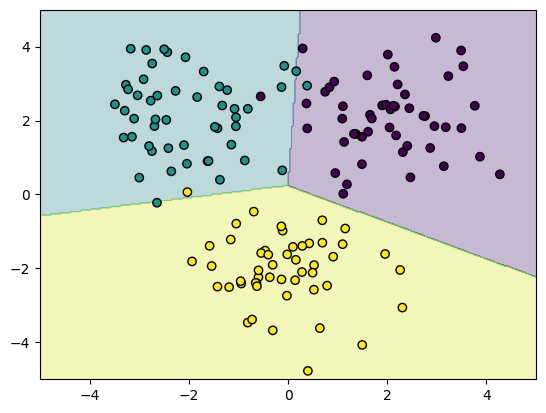

In [57]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z)
    return expZ / expZ.sum(axis=1, keepdims=True)

def loss(X, Y, W):
    P = softmax(X @ W.T)
    return -np.sum(Y * np.log(P + 1e-12))

def grad(X, Y, W):
    P = softmax(X @ W.T)
    return (P - Y).T @ X

np.random.seed(0)

N = 50
X1 = np.random.randn(N,2) + [2,2]
X2 = np.random.randn(N,2) + [-2,2]
X3 = np.random.randn(N,2) + [0,-2]

X = np.vstack([X1,X2,X3])
y = np.array([0]*N + [1]*N + [2]*N)

# bias
X = np.hstack([np.ones((X.shape[0],1)), X])

# one-hot
M = 3
Y = np.zeros((len(y), M))
Y[np.arange(len(y)), y] = 1

W = np.zeros((M, X.shape[1]))
lr = 0.05

for _ in range(2000):
    W -= lr * grad(X, Y, W)
    
xx, yy = np.meshgrid(
    np.linspace(-5,5,300),
    np.linspace(-5,5,300)
)

Xg = np.c_[np.ones(xx.size), xx.ravel(), yy.ravel()]
Z = Xg @ W.T
pred = np.argmax(Z, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, pred, alpha=0.3)
plt.scatter(X[:,1], X[:,2], c=y, edgecolor="k")
plt.show()
